In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [78]:
df=pd.read_csv("Fraud Detection Dataset.csv")
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [79]:
df.tail()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
50995,T33982,2339,3112.51,Bill Payment,15.0,Mobile,New York,0,7,8,Debit Card,0
50996,T31261,2152,2897.15,Online Purchase,3.0,Mobile,Miami,1,75,11,Net Banking,1
50997,T12293,3345,2204.43,POS Payment,18.0,Mobile,San Francisco,3,73,5,Credit Card,0
50998,T42287,1518,4787.17,POS Payment,19.0,Tablet,New York,2,108,14,Net Banking,0
50999,T13665,2315,814.72,POS Payment,3.0,Tablet,Los Angeles,0,50,10,Invalid Method,0


In [80]:
df.dtypes

Transaction_ID                          str
User_ID                               int64
Transaction_Amount                  float64
Transaction_Type                        str
Time_of_Transaction                 float64
Device_Used                             str
Location                                str
Previous_Fraudulent_Transactions      int64
Account_Age                           int64
Number_of_Transactions_Last_24H       int64
Payment_Method                          str
Fraudulent                            int64
dtype: object

In [81]:
df.shape

(51000, 12)

In [82]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51000 entries, 0 to 50999
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Transaction_ID                    51000 non-null  str    
 1   User_ID                           51000 non-null  int64  
 2   Transaction_Amount                48480 non-null  float64
 3   Transaction_Type                  51000 non-null  str    
 4   Time_of_Transaction               48448 non-null  float64
 5   Device_Used                       48527 non-null  str    
 6   Location                          48453 non-null  str    
 7   Previous_Fraudulent_Transactions  51000 non-null  int64  
 8   Account_Age                       51000 non-null  int64  
 9   Number_of_Transactions_Last_24H   51000 non-null  int64  
 10  Payment_Method                    48531 non-null  str    
 11  Fraudulent                        51000 non-null  int64  
dtypes: float64(2), 

In [83]:
df.describe()

,User_ID,Transaction_Amount,Time_of_Transaction,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Fraudulent
count,51000.000000,48480.000000,48448.000000,51000.000000,51000.000000,51000.000000,51000.000000
mean,3005.110176,2996.249784,11.488400,1.995725,60.033902,7.495588,0.049216
std,1153.121107,5043.932555,6.922954,1.415150,34.384131,4.020080,0.216320
min,1000.000000,5.030000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,2007.000000,1270.552500,5.000000,1.000000,30.000000,4.000000,0.000000
50%,2996.000000,2524.100000,12.000000,2.000000,60.000000,7.000000,0.000000
75%,4006.000000,3787.240000,17.000000,3.000000,90.000000,11.000000,0.000000
max,4999.000000,49997.800000,23.000000,4.000000,119.000000,14.000000,1.000000


In [84]:
doublons=df.duplicated().sum()
print(f"le nombre de doublons est {doublons}")

le nombre de doublons est 881


In [85]:
df=df.drop_duplicates()

In [86]:
df.shape

(50119, 12)

# L' EDA : Faisons l' analyse des valeurs manquantes

In [87]:
df.isnull().sum()

Transaction_ID                         0
User_ID                                0
Transaction_Amount                  2476
Transaction_Type                       0
Time_of_Transaction                 2505
Device_Used                         2437
Location                            2500
Previous_Fraudulent_Transactions       0
Account_Age                            0
Number_of_Transactions_Last_24H        0
Payment_Method                      2428
Fraudulent                             0
dtype: int64

<Axes: >

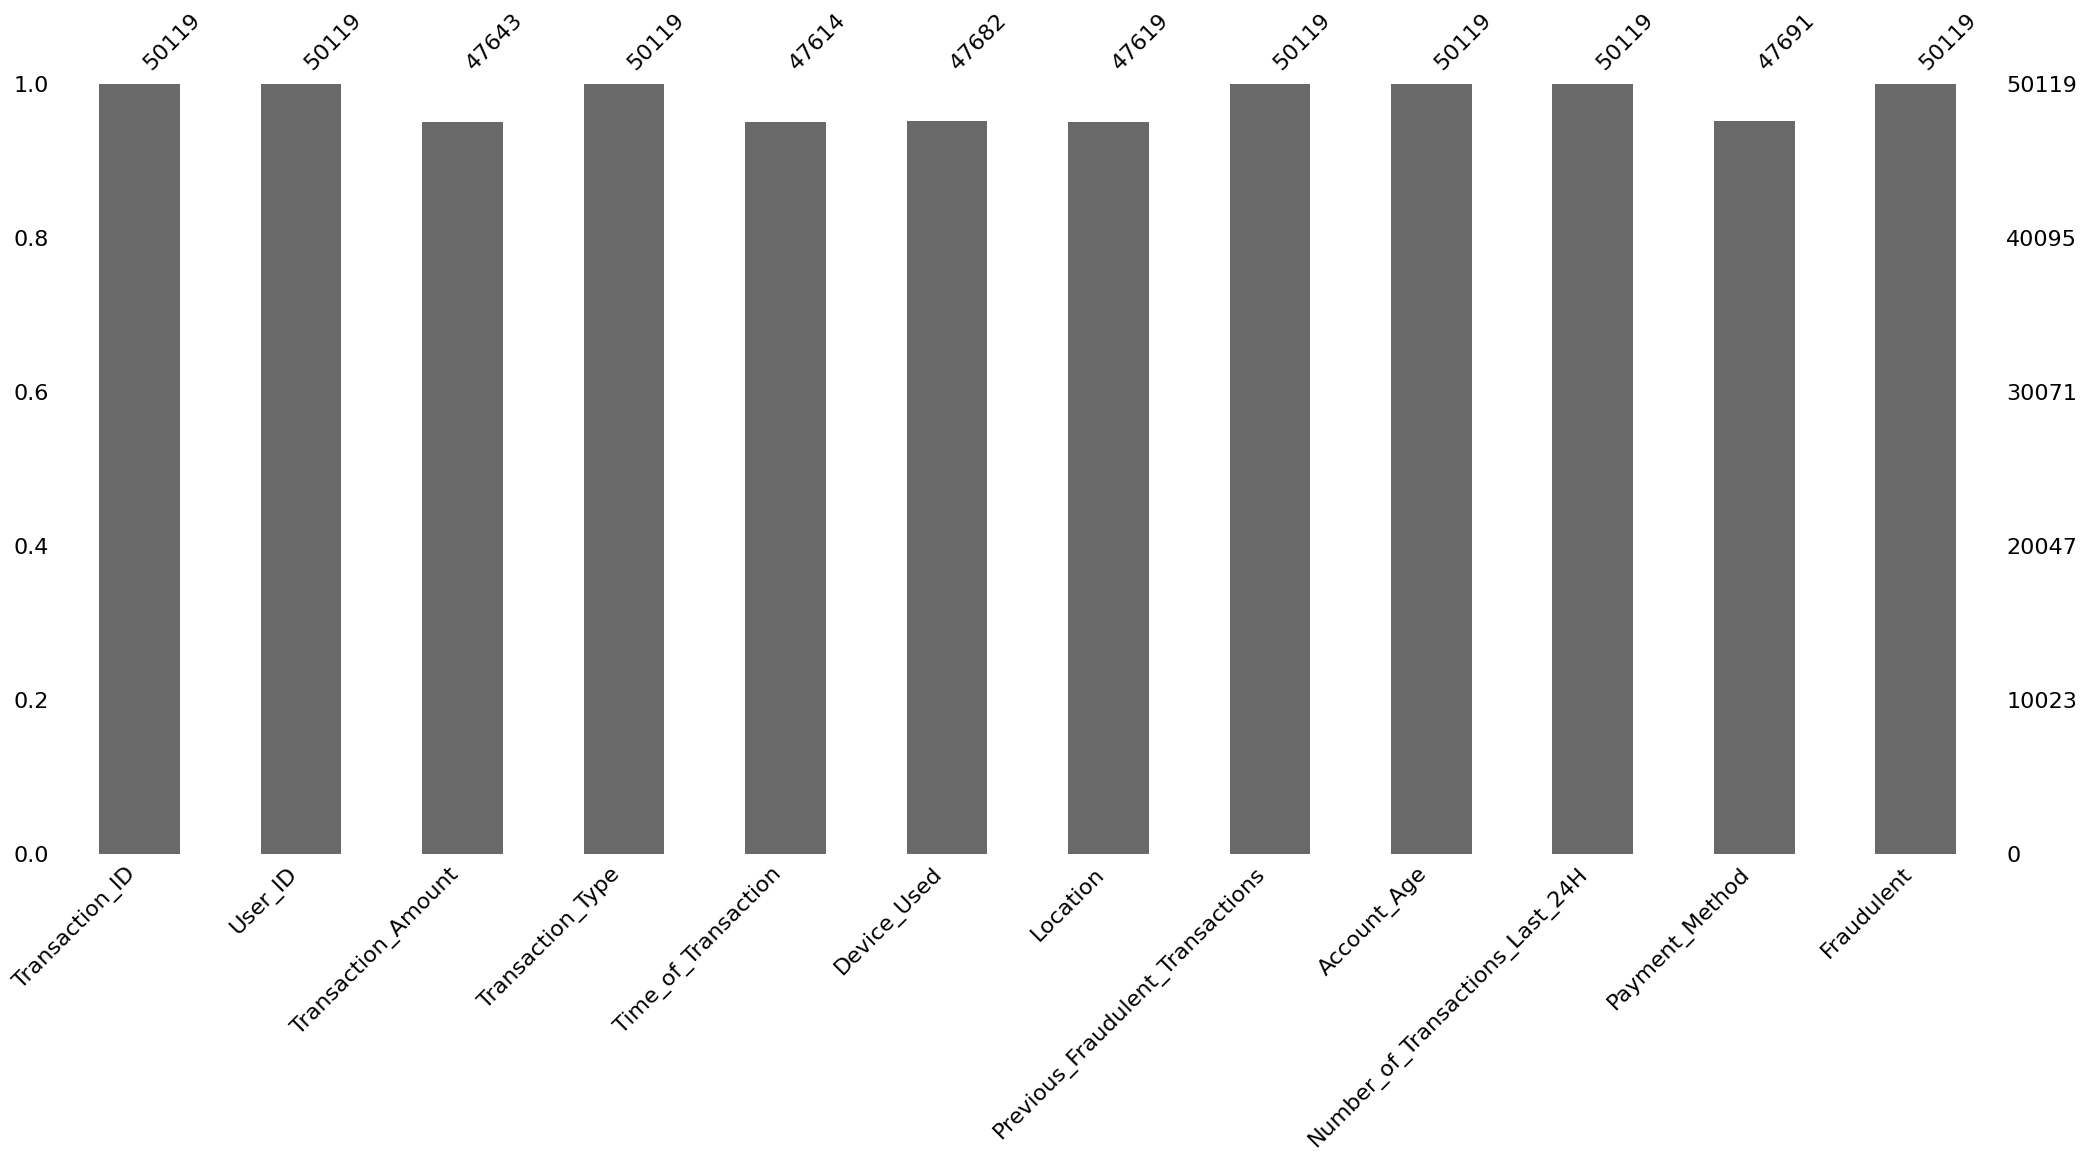

In [88]:
msno.bar(df)

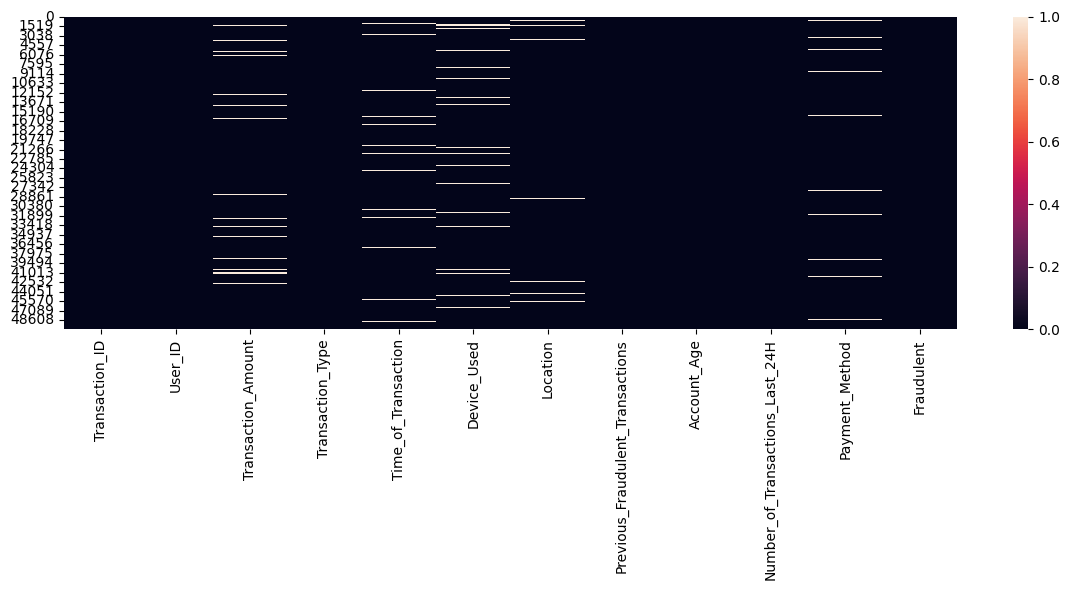

In [89]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    df.isnull(),

)

plt.tight_layout()
plt.show()


# Distribution des variables

Voyons tout d'abord les variables numériques

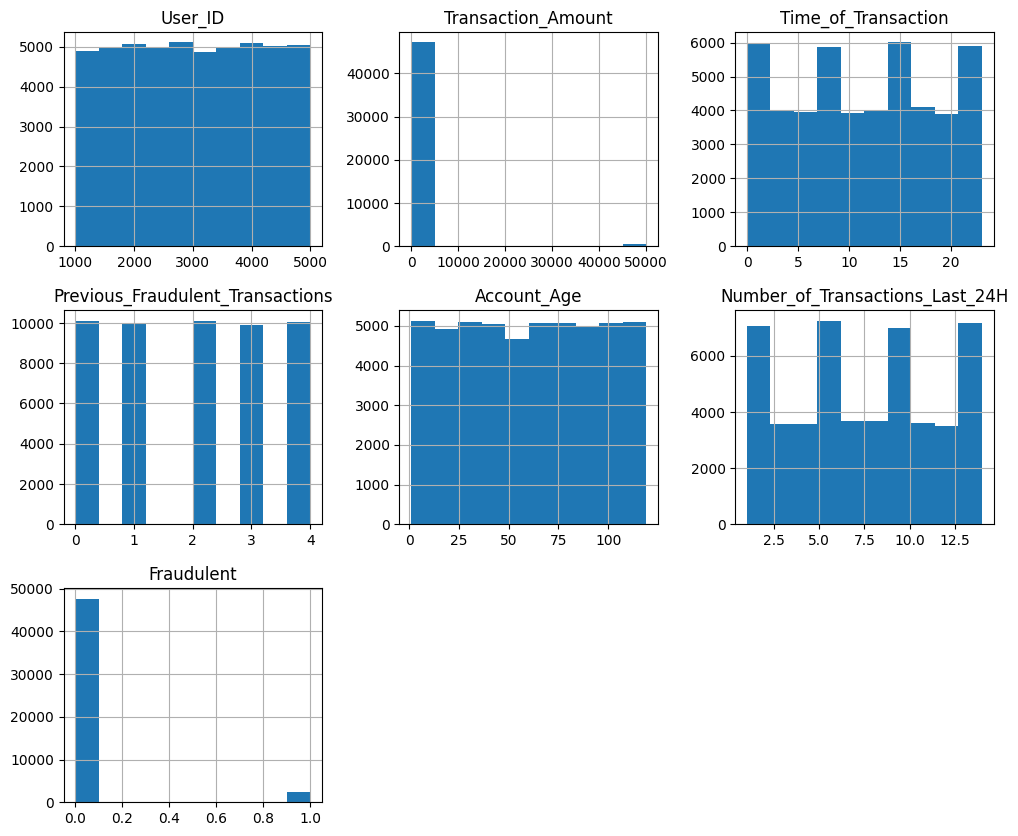

In [90]:
df.hist(figsize=(12,10))
plt.show()

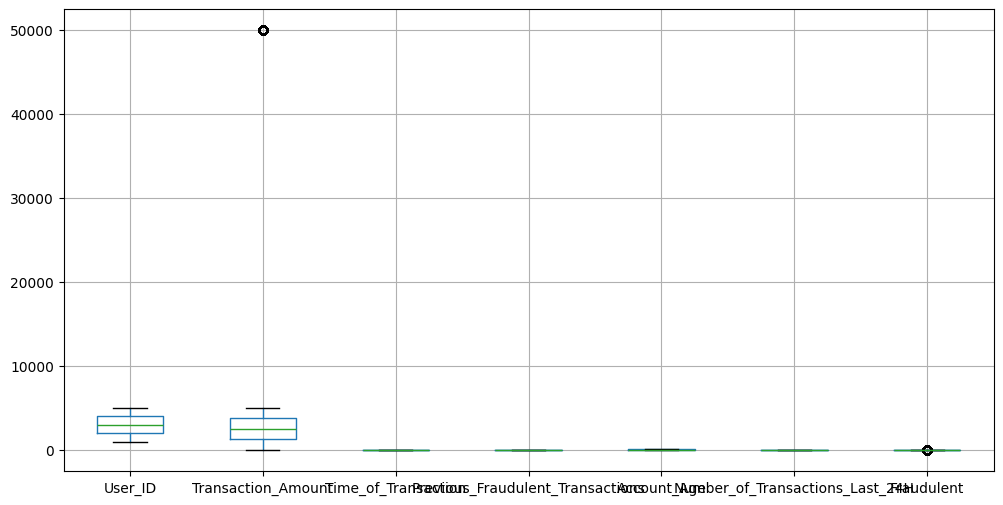

In [91]:
df.boxplot(figsize=(12,6))
plt.show()

Maintenant voyons les variables catégorielles

In [92]:
from IPython.display import display

display(df['Transaction_ID'].value_counts())
display(df['Transaction_Type'].value_counts())
display(df['Device_Used'].value_counts())
display(df['Location'].value_counts())
display(df['Payment_Method'].value_counts())

Transaction_ID
T509      2
T629      2
T660      2
T726      2
T1445     2
         ..
T49996    1
T49997    1
T49998    1
T49999    1
T50000    1
Name: count, Length: 50000, dtype: int64

Transaction_Type
Bill Payment       10161
Bank Transfer      10110
ATM Withdrawal      9979
POS Payment         9957
Online Purchase     9912
Name: count, dtype: int64

Device_Used
Desktop           15524
Mobile            15321
Tablet            15307
Unknown Device     1530
Name: count, dtype: int64

Location
Boston           6037
New York         6003
Seattle          6001
Chicago          5968
Houston          5935
Los Angeles      5910
Miami            5884
San Francisco    5881
Name: count, dtype: int64

Payment_Method
UPI               11671
Debit Card        11614
Net Banking       11462
Credit Card       11417
Invalid Method     1527
Name: count, dtype: int64

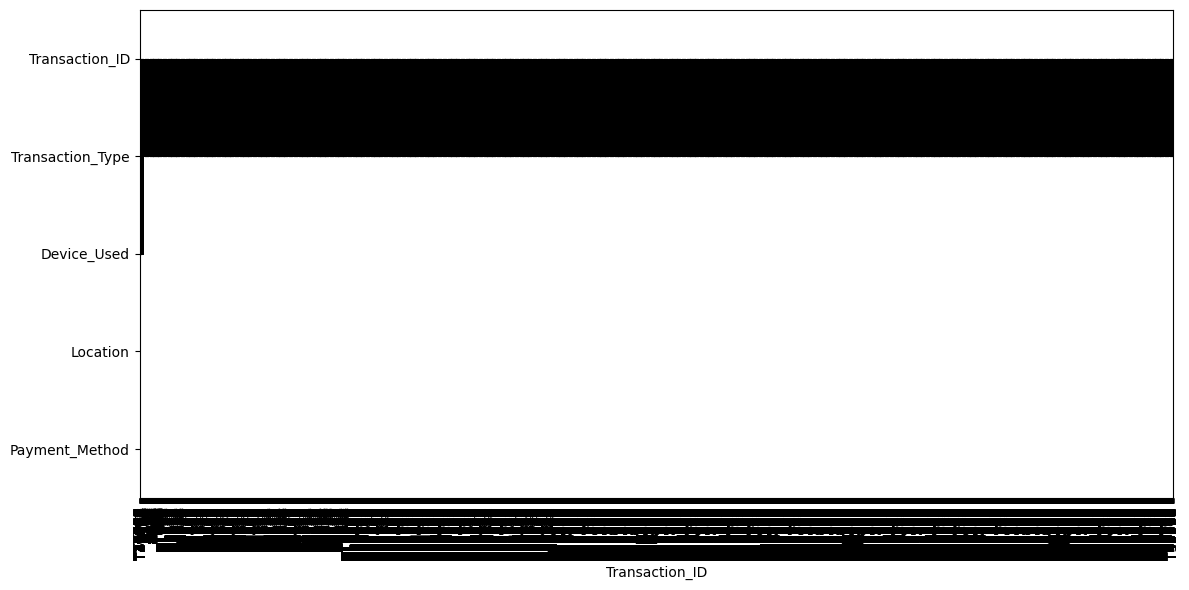

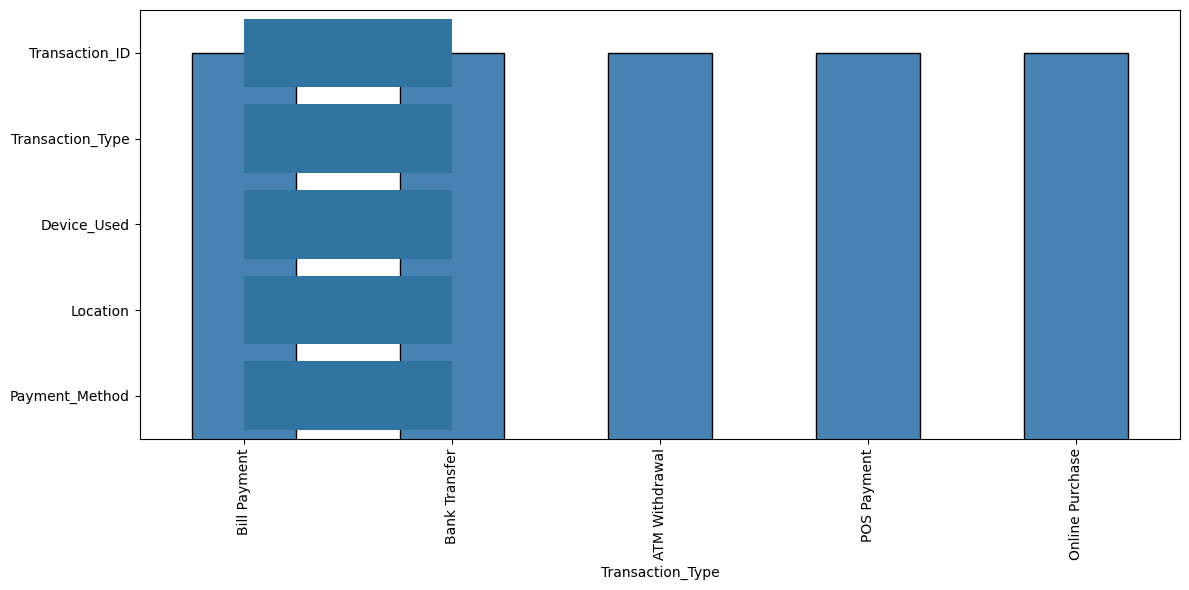

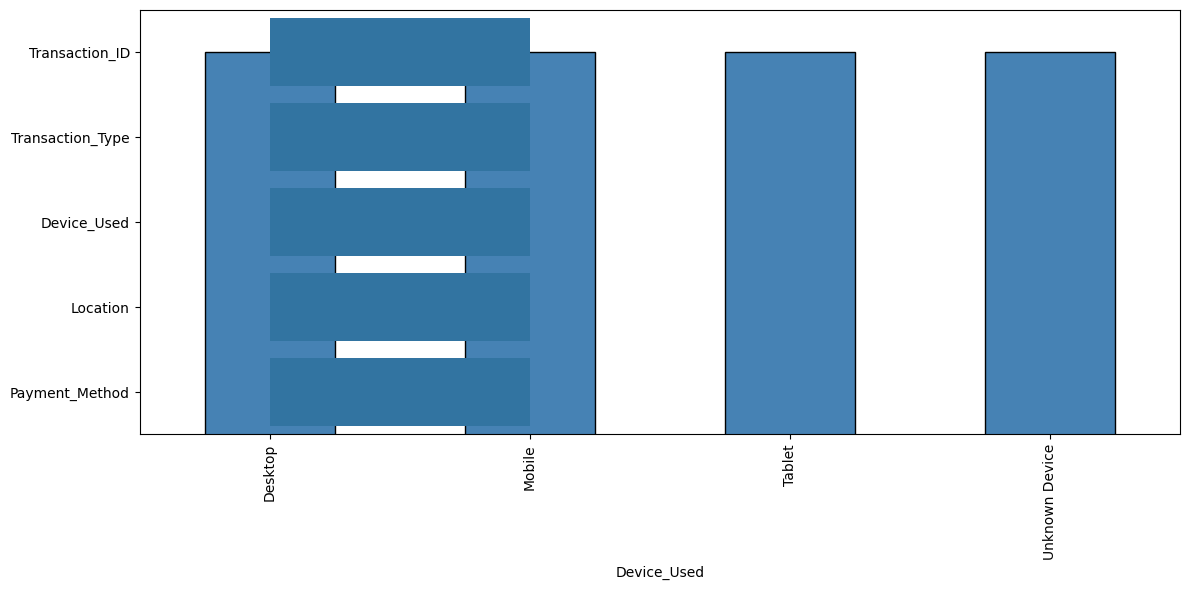

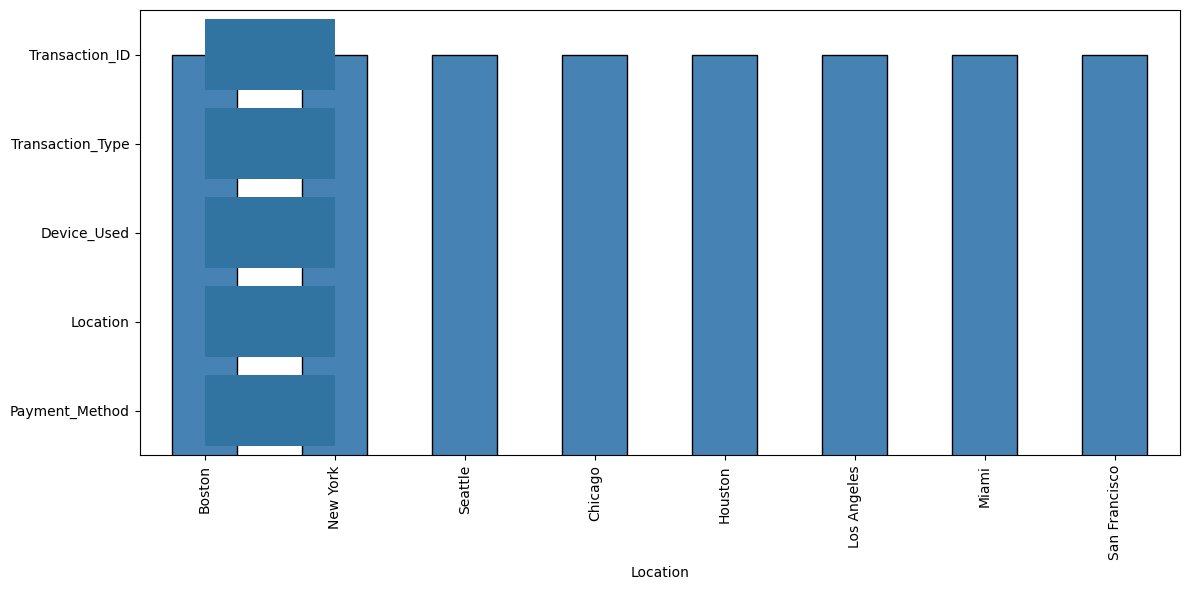

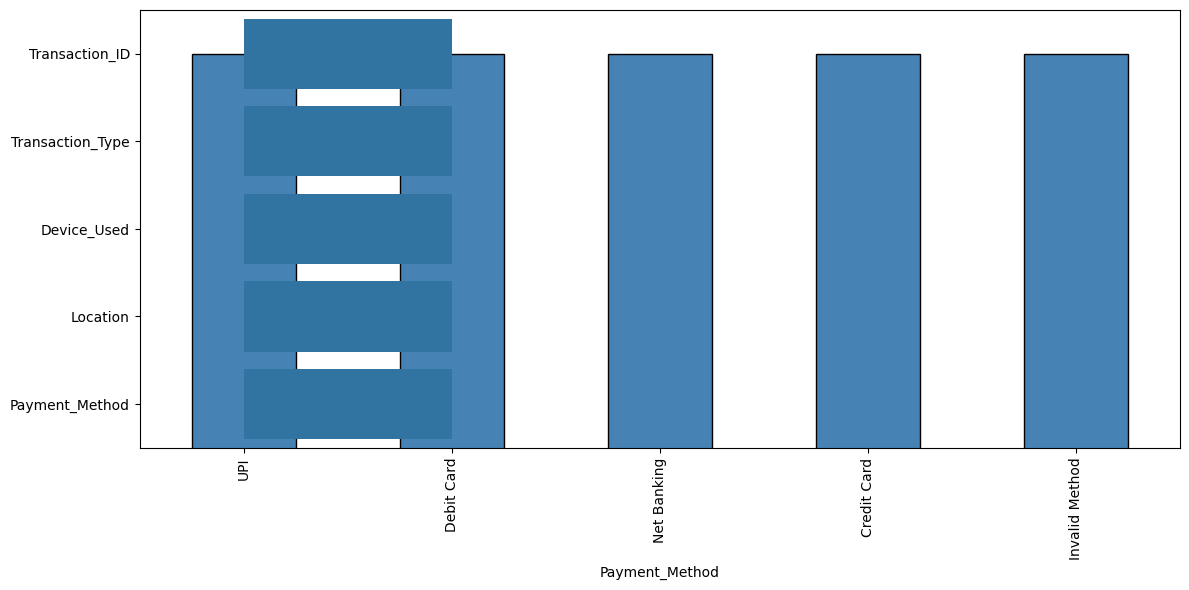

In [93]:

colmuns=["Transaction_ID", "Transaction_Type", "Device_Used", "Location", "Payment_Method"]

for colmun in colmuns:
    plt.figure(figsize=(12,6))
    df[colmun].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
    sns.countplot(
        data=colmuns
    )

    plt.tight_layout()
    plt.show()

voyons alors la variable cible

In [94]:
df.head()

,Transaction_ID,User_ID,Transaction_Amount,Transaction_Type,Time_of_Transaction,Device_Used,Location,Previous_Fraudulent_Transactions,Account_Age,Number_of_Transactions_Last_24H,Payment_Method,Fraudulent
0,T1,4174,1292.76,ATM Withdrawal,16.0,Tablet,San Francisco,0,119,13,Debit Card,0
1,T2,4507,1554.58,ATM Withdrawal,13.0,Mobile,New York,4,79,3,Credit Card,0
2,T3,1860,2395.02,ATM Withdrawal,NaN,Mobile,NaN,3,115,9,NaN,0
3,T4,2294,100.10,Bill Payment,15.0,Desktop,Chicago,4,3,4,UPI,0
4,T5,2130,1490.50,POS Payment,19.0,Mobile,San Francisco,2,57,7,Credit Card,0


In [95]:
 df['Fraudulent'].value_counts()

Fraudulent
0    47652
1     2467
Name: count, dtype: int64

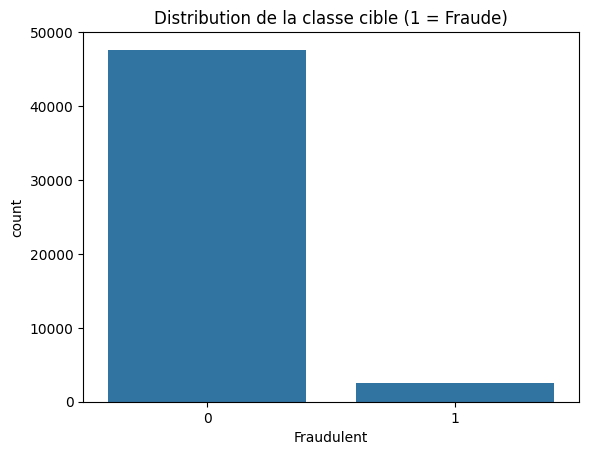

In [97]:
sns.countplot(x='Fraudulent', data=df)
plt.title("Distribution de la classe cible (1 = Fraude)")
plt.show()

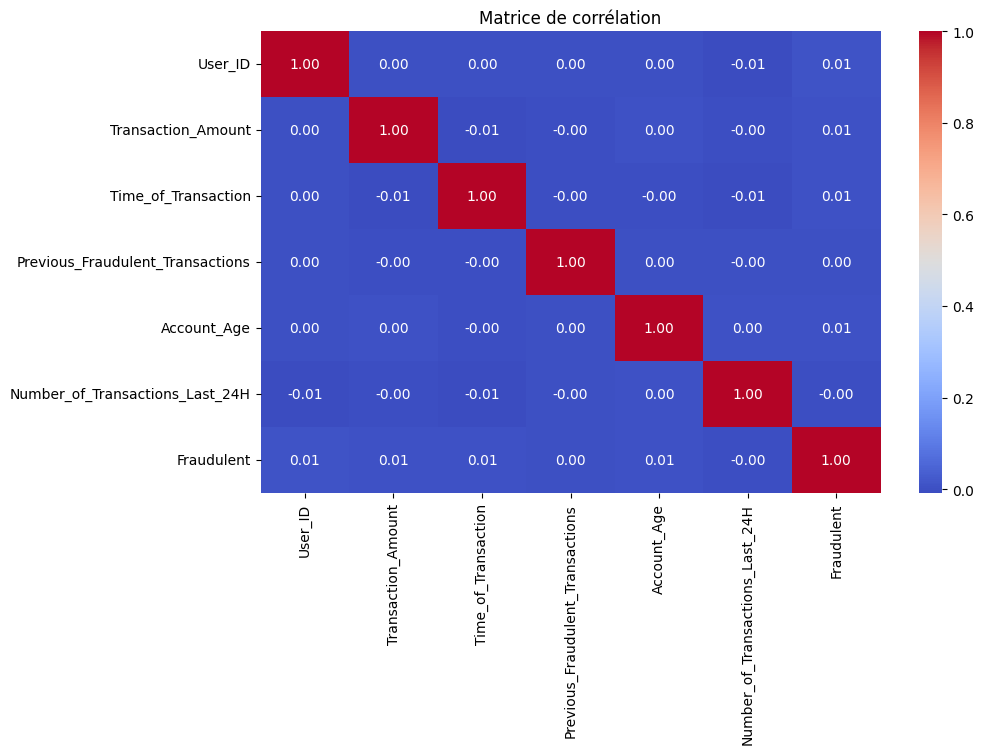

In [98]:
#Matrice de corrélation

#Corrélations (uniquement numériques)
plt.figure(figsize=(10,6))
sns.heatmap(df.select_dtypes(include=[np.number]).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Matrice de corrélation")
plt.show()


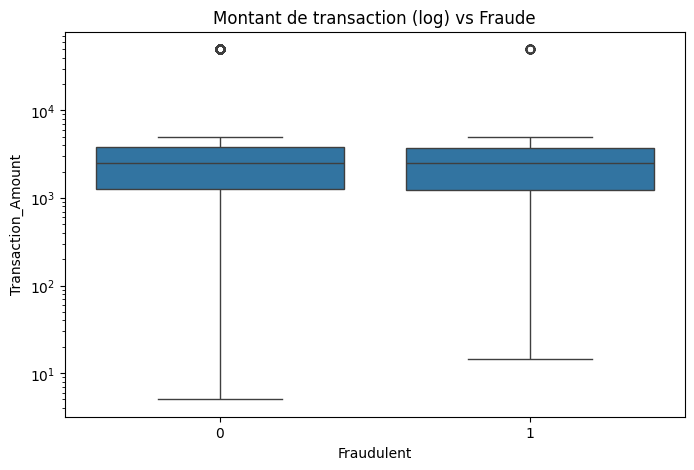

In [99]:
# Boxplot du montant selon fraude
plt.figure(figsize=(8,5))
sns.boxplot(x='Fraudulent', y='Transaction_Amount', data=df)
plt.yscale('log')
plt.title("Montant de transaction (log) vs Fraude")
plt.show()

# Feature engineering

In [106]:
# Nettoyage des IDs inutiles
df.drop(['Transaction_ID', 'User_ID'], axis=1, inplace=True)

In [107]:
# Séparation des features

X=df.drop(columns=['Fraudulent'])
y=df['Fraudulent']

# Identification des colonnes numériques et catégorielles
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

print(f" Colonnes numériques : {num_cols}")
print(f" Colonnes catégorielles : {cat_cols}")

 Colonnes numériques : ['Transaction_Amount', 'Time_of_Transaction', 'Previous_Fraudulent_Transactions', 'Account_Age', 'Number_of_Transactions_Last_24H']
 Colonnes catégorielles : ['Transaction_Type', 'Device_Used', 'Location', 'Payment_Method']


C:\Users\BELLOW\AppData\Local\Temp\ipykernel_32700\699522792.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()


In [108]:
# PIPELINE DE PREPROCESSING

# Pipeline pour les numériques
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Pipeline pour les catégorielles
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine
preprocessor = ColumnTransformer([
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

In [ ]:
# Entrainons le modèle

model=DecisionTreeClassifier(criterion='entropy', min_samples_leaf=5,random_state=42)

# Pipeline complet
pipeline = Pipeline([
    ('prep', preprocessor),
    ('clf', model)
])

# Grille de paramètres pour GridSearchCV
param_grid = {
    'clf__max_depth': [3, 5, 10, 15, None],
    'clf__min_samples_split': [2, 5, 10, 20],
    'clf__min_samples_leaf': [1, 2, 5, 10],
    'clf__criterion': ['gini', 'entropy'],
    'clf__class_weight': [None, 'balanced']
}

# GridSearchCV avec validation croisée
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

# Divisons le dataset en training et testing 
X_train,X_test,y_train,y_test=train_test_split(X,y ,test_size=0.2, random_state=42, stratify=y)

grid_search.fit(X_train,y_train)



Fitting 5 folds for each of 320 candidates, totalling 1600 fits


In [ ]:
# Evaluation du model

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=['Non Fraude', 'Fraude']))

print(" MATRICE DE CONFUSION")
print("="*50)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non Fraude', 'Fraude'], 
            yticklabels=['Non Fraude', 'Fraude'])
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de confusion')
plt.show()

# ROC-AUC
roc_auc = roc_auc_score(y_test, y_proba)
print(f"\n ROC-AUC Score : {roc_auc:.4f}")

# Courbe ROC
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure()
plt.plot(fpr, tpr, label=f'Decision Tree (AUC = {roc_auc:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()